In [2]:
import netCDF4 as nc
import pandas as pd
import numpy as np

file_path = "Rx5day.nc"
ds = nc.Dataset(file_path, 'r')

#for var in ds.variables:
#    print(f"  - Variable: {var}")
#    print(f"    Dimensions: {ds.variables[var].dimensions}")
#    print(f"    Shape: {ds.variables[var].shape}")

rx5day = ds.variables['rx5dayETCCDI'][:]  
#print(f"Valeurs manquantes : {np.isnan(rx5day).sum()}")

#conversion des longitudes nécessaire
lat = ds.variables['lat'][:]
lon = ds.variables['lon'][:]

lon_adj = np.where(lon > 180, lon - 360, lon)
sort_idx = np.argsort(lon_adj)
lon_sorted = lon_adj[sort_idx]
rx5day_sorted = rx5day[:, :, sort_idx]  
rx5day=rx5day_sorted
lon=lon_sorted
#print(f"lat.shape = {lat.shape}, lon.shape = {lon.shape}")
#print(f"rx5day.shape = {rx5day.shape} (doit être (time, lat.shape[0], lon.shape[0]))")
#print(f"lat.shape[0] == len(lat) : {lat.shape[0] == len(lat)}")
#print(f"lon.shape[0] == len(lon) : {lon.shape[0] == len(lon)}")
#print(f"rx5day.shape[1] == lat.shape[0] : {rx5day.shape[1] == lat.shape[0]}")
#print(f"rx5day.shape[2] == lon.shape[0] : {rx5day.shape[2] == lon.shape[0]}")   
#Normalement, les pixels sont organisés en une grille régulière, donc les dimensions de lat et lon devraient correspondre à celles de rx5day.

time = ds.variables['time'][:]
#time_bounds=ds.variables['time_bounds'][:] # -> nombre de jour entre chaque date, bornes temporelles  
t_units = ds.variables['time'].units
t_calendar = ds.variables['time'].calendar if hasattr(ds.variables['time'], 'calendar') else 'standard'
#print (t_units, "\n",t_calendar)
dates_python = nc.num2date(time, units=t_units, calendar=t_calendar)#convertir les dates en format datetime
dates = [pd.Timestamp(f"{d.year}-{d.month:02d}-{d.day:02d}") for d in dates_python]
#print (dates[:5])

df = pd.DataFrame(
    rx5day.reshape(len(dates), -1), #on passe de 3 dimensions (time, lat, lon) à 2 dimensions (time, pixels)
    index=dates,
    columns=[f"lat_{lat[i]:.2f}_lon_{lon[j]:.2f}" for i in range(len(lat)) for j in range(len(lon))]
)
array = df.values.reshape(len(dates), len(lat), len(lon), 1)
#print(df.head())
#print("\nForme de l'array 4D :", array_4d.shape)
ds.close()

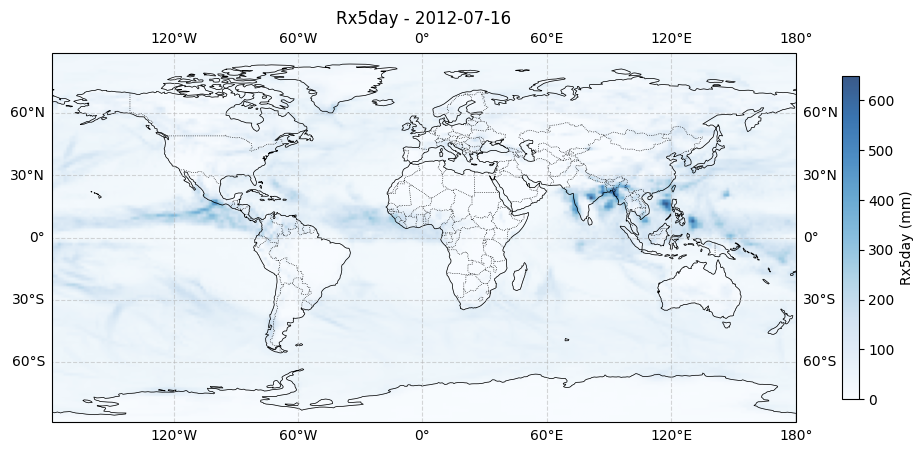

In [3]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from netCDF4 import num2date

#rng = np.random.default_rng(seed=42)
#idx = rng.integers(0, len(dates)) #at random
idx=1950
the_date = dates[idx]
data_img = array[idx, :, :, 0]  

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.imshow(data_img, extent=[lon.min(), lon.max(), lat.min(), lat.max()],
               origin='lower', cmap='Blues', alpha=0.8,
               transform=ccrs.PlateCarree())

ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)  

plt.colorbar(im, label='Rx5day (mm)', shrink=0.7)
ax.set_title(f'Rx5day - {the_date.strftime("%Y-%m-%d")}')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

plt.show()

In [4]:
#print(f"Longitudes min et max : {lon.min():.1f}, {lon.max():.1f}")
#lon_centered = np.where(lon > 180, lon - 360, lon)
#print(lon_centered)
lat_min, lat_max = 41.0, 52.0   
lon_min, lon_max = -5.0, 9.0
lat_indices = np.where((lat >= lat_min) & (lat <= lat_max))[0]
#lon_indices = np.where((lon_centered >= lon_min) & (lon_centered <= lon_max))[0]
lon_indices = np.where((lon >= lon_min) & (lon <= lon_max))[0]
#print(lon_indices)

lat_france = lat[lat_indices]
lon_france = lon[lon_indices]
print(lat_france, "\n", lon_france)

array_fr= array[:, lat_indices, :, :][:, :, lon_indices, :]  # (time, len(lat_indices), len(lon_indices), 1)
print(array_fr.shape)
#8x9, 1980 observations temporelles, 1 variable (Rx5day) -> (1980, 7, 9, 1)



[41.32257587 42.72333486 44.12409297 45.5248501  46.92560615 48.32636102
 49.72711456 51.12786664] 
 [-4.21875 -2.8125  -1.40625  0.       1.40625  2.8125   4.21875  5.625
  7.03125  8.4375 ]
(1980, 8, 10, 1)


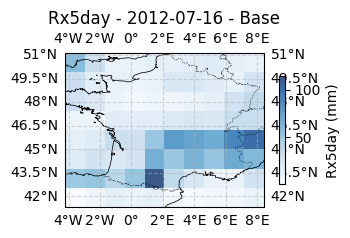

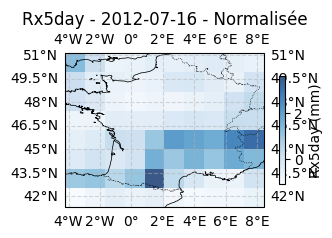

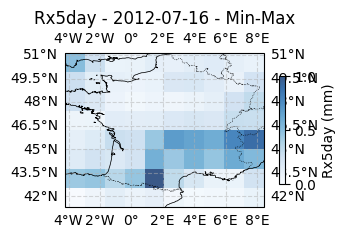

In [5]:
idx=1950
the_date = dates[idx]
img_base = array_fr[idx, :, :, 0]  
m = img_base.mean()
std = img_base.std()
img_norma= (img_base - m) / std

img_min = img_base.min()
img_max = img_base.max()
img_minmax = (img_base - img_min) / (img_max - img_min)

for img in [img_base, img_norma, img_minmax]:
    fig = plt.figure(figsize=(4, 2))
    ax = plt.axes(projection=ccrs.PlateCarree())

    #Ajuster les limites de l'image pour correspondre à la région de la France
    im = ax.imshow(img, extent=[lon_france.min(), lon_france.max(), lat_france.min(), lat_france.max()],
                origin='lower', cmap='Blues', alpha=0.8,
                transform=ccrs.PlateCarree())
    #ax.set_extent([lon_france.min(), lon_france.max(),                lat_france.min(), lat_france.max()],               crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND, facecolor='white', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3)  

    plt.colorbar(im, label='Rx5day (mm)', shrink=0.7)
    ax.set_title(f'Rx5day - {the_date.strftime("%Y-%m-%d")} - {"Base" if img is img_base else "Normalisée" if img is img_norma else "Min-Max"}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

    plt.show()


In [6]:
#analyse de distribution des données ?

In [7]:
#VAE

In [8]:
#Package du prof
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras
from keras import layers
#from modules.layers    import SamplingLayer, VariationalLossLayer
from fonction_en_plus.ImagesCallback import ImagesCallback
import sys
import fidle


In [10]:
latent_dim    = 4  #4-6: équilibré// 6-12: plus de capacité, mais risque de surapprentissage
loss_weights  = [1,.06] # 1 Reconstruction loss et 0.06 KL loss opti ressemblance loi 
#la tâche de recontsruction est + difficile que la tache de prediction de mean et var
seed=42

batch_size    = 4
epochs        = 8 #16 était trop pr peu d'avance 
fit_verbosity = 1

# dim, weight a tester tester

In [11]:
# ne devrait on pas split le data set selon les saisons ?
#pour avoir des résultats corrects, et pas juste une moyenne sur les 40 ans de données ?

oups_data = array_fr
#mean = oups_data.mean()
#std = oups_data.std()
#x_data= (oups_data - mean) / std

#pref ?
x_min = oups_data.min()
x_max = oups_data.max()
x_data = (oups_data - x_min) / (x_max - x_min)

print(x_data.min(), x_data.max())


0.0 1.0


In [12]:
#Encoder

In [13]:
import torch
from torch.distributions.normal import Normal

class Sampling(layers.Layer):
    #Utilise (z_mean, z_log_var) pour échantillonner z, en utilisant la technique de reparamétrisation    
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch_size,latent_dim = z_mean.shape
        epsilon = Normal(0, 1).sample((batch_size, latent_dim)).to(z_mean.device)
        z = z_mean + torch.exp(0.5 * z_log_var) * epsilon 
        return z

In [14]:
class VAELL (keras.layers.Layer):
   
    def __init__(self, loss_weights=[3,7]):
        super().__init__()
        self.k1 = loss_weights[0]
        self.k2 = loss_weights[1]


    def call(self, inputs):
        k1 = self.k1
        k2 = self.k2
        
        x, z_mean, z_log_var, y = inputs
        
        #Reconstruction loss         
        r_loss = torch.nn.functional.binary_cross_entropy(y, x, reduction='sum')
        
        #KL loss
        kl_loss = - torch.sum(1+ z_log_var - z_mean.pow(2) - z_log_var.exp())
        
        # Total Loss
        loss = r_loss*k1 + kl_loss*k2
        self.add_loss(loss)
        
        return y

    
    def get_config(self):
        return {'loss_weights':[self.k1,self.k2]}
        # To keep track of the loss weights in checkpoints and logs,
        # we need to implement get_config() so that Keras can properly serialize them.

In [15]:
inputs    = keras.Input(shape=(8, 10, 1)) #taille image en entrée
x = layers.Conv2D(16, 3, strides=1, padding="same", activation="relu")(inputs)
x         = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(x)
x         = layers.Flatten()(x)
x         = layers.Dense(64, activation="relu")(x)

z_mean    = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x) # log or not ?
z         = Sampling()([z_mean, z_log_var])

encoder = keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")

#encoder.summary()

In [16]:
#decoder

In [17]:
inputs  = keras.Input(shape=(latent_dim,))
x       = layers.Dense(4 * 5 * 32, activation="relu")(inputs) #même taille que la dernière couche de l'encoder  
x       = layers.Reshape((4, 5, 32))(x) # reshape objectif : retrouver la taille de la dernière couche de l'encoder pour pouvoir faire du transposed convolution
x       = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")(x)
# on force la taille de sortie pour éviter les problèmes de dimension lors du upsampling
#outputs = layers.Conv2DTranspose(1,  3, padding="same", activation="linear")(x)
outputs = layers.Conv2DTranspose(1,  3, padding="same", activation="sigmoid")(x)

#car donnée normalisée, on peut sortir des valeurs négatives, d'où activation linéaire

decoder = keras.Model(inputs, outputs, name="decoder")

#decoder.summary()

In [18]:
inputs  = keras.Input(shape=(8, 10, 1))
z_mean, z_log_var, z = encoder(inputs)
outputs              = decoder(z)

outputs = VAELL(loss_weights=loss_weights)([inputs, z_mean, z_log_var, outputs])

vae     = keras.Model(inputs,outputs)

vae.compile(optimizer='adam', loss=None)

In [19]:
run_dir = '.'

callback_images  = ImagesCallback(x=x_data, z_dim=latent_dim, nb_images=5, from_z=True, from_random=True, run_dir=run_dir)

callbacks_list = [callback_images]


In [20]:
chrono=fidle.Chrono()
chrono.start()

history = vae.fit(x_data, epochs=epochs, batch_size=batch_size, 
                  callbacks=callbacks_list, 
                  verbose=fit_verbosity)

chrono.show()

Epoch 1/8
  3/495 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 221.6914  

c:\Users\admin\Desktop\GEN ai\Projet\.venv\Lib\site-packages\keras\src\backend\common\backend_utils.py:100: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/stepstep - loss: 131.577
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
495/495 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - loss: 115.9540
Epoch 2/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/stepstep - loss: 109.204
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
495/495 ━━━━━━━━━━━━━━━━━━━━ 16s 32ms/step - loss: 108.3335
Epoch 3/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/stepstep - loss: 107.67
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
495/495 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - loss: 107.6579
Epoch 4/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/stepstep - loss: 107.571
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
495/495 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - loss: 107.5470
Epoch 5/8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/stepstep - loss: 107.068
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
495/495 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - loss: 

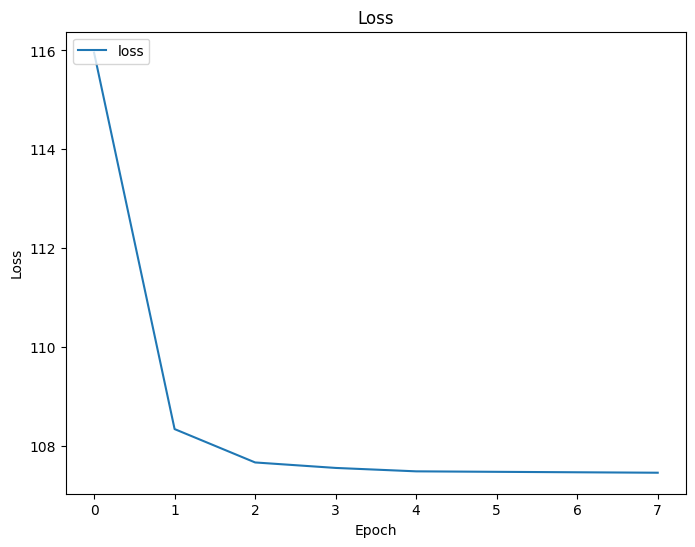

In [21]:
fidle.scrawler.history(history,  plot={"Loss":['loss']})

<br>**Original images :**

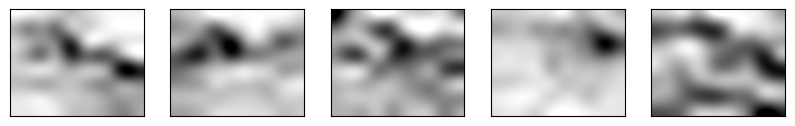

<br>**Encoded/decoded images**

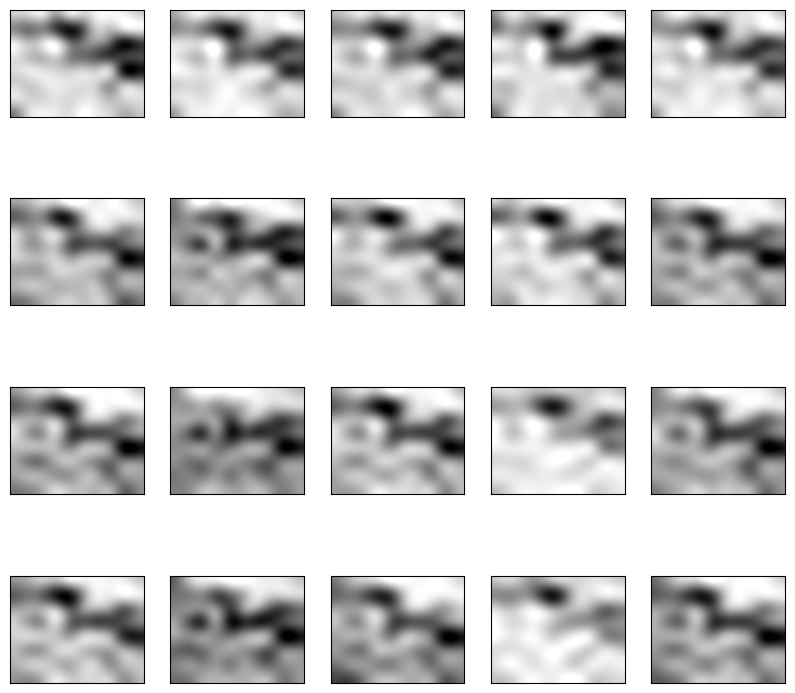

<br>**Original images :**

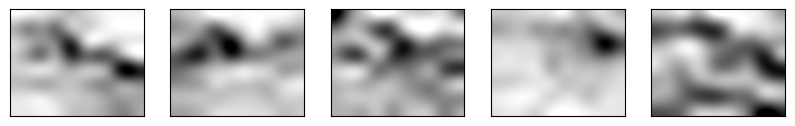

In [22]:
images_z, images_r = callback_images.get_images( range(0,epochs,2) )
#Utilité ?

#fidle.utils.subtitle('Original images :')
#fidle.scrawler.images(x_data[:3], None, indices='all', columns=5, x_size=2,y_size=2)

#fidle.utils.subtitle('Encoded/decoded images')
#fidle.scrawler.images(images_z[:3], None, indices='all', columns=5, x_size=2,y_size=2)

#fidle.utils.subtitle('Generated images from latent space')
#fidle.scrawler.images(images_r[:3], None, indices='all', columns=5, x_size=2,y_size=2)

images_z, images_r = callback_images.get_images( range(0,epochs,2) )

fidle.utils.subtitle('Original images :')
fidle.scrawler.images(x_data[:5], None, indices='all', columns=5, x_size=2,y_size=2, save_as='02-original')

fidle.utils.subtitle('Encoded/decoded images')
fidle.scrawler.images(images_z, None, indices='all', columns=5, x_size=2,y_size=2, save_as='03-reconstruct')

fidle.utils.subtitle('Original images :')
fidle.scrawler.images(x_data[:5], None, indices='all', columns=5, x_size=2,y_size=2, save_as=None)


c:\Users\admin\Desktop\GEN ai\Projet\.venv\Lib\site-packages\keras\src\backend\common\backend_utils.py:100: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


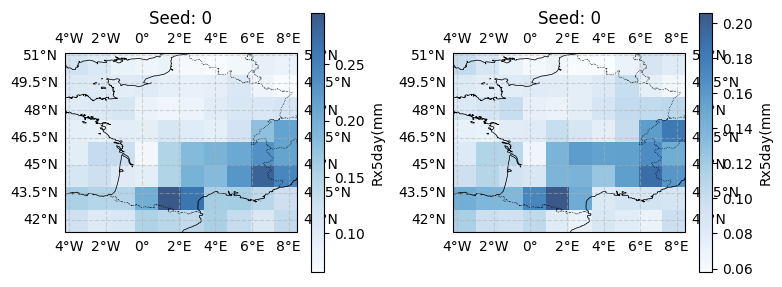

c:\Users\admin\Desktop\GEN ai\Projet\.venv\Lib\site-packages\keras\src\backend\common\backend_utils.py:100: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


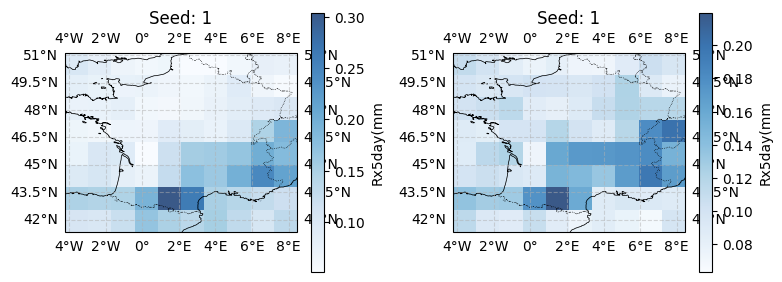

c:\Users\admin\Desktop\GEN ai\Projet\.venv\Lib\site-packages\keras\src\backend\common\backend_utils.py:100: UserWarning: You might experience inconsistencies across backends when calling conv transpose with kernel_size=3, stride=2, dilation_rate=1, padding=same, output_padding=1.
  warnings.warn(


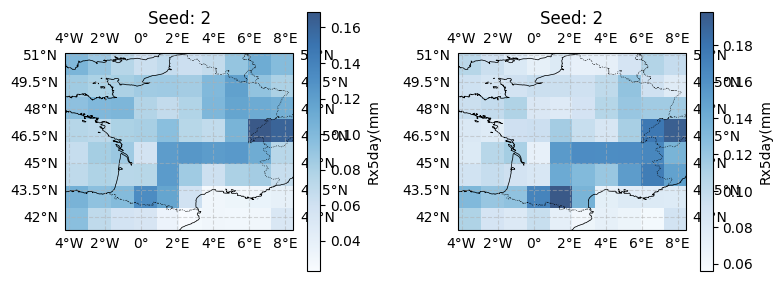

In [23]:
n = 2
m=3
for i in range(m):
    seed=i
    decoder = vae.get_layer('decoder')
    z_sample = np.random.normal(size=(n, latent_dim))
    imgs = decoder(z_sample).detach().cpu().numpy()

    fig, axes = plt.subplots(1, n, figsize=(n*4, 4), subplot_kw={'projection': ccrs.PlateCarree()})

    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        image = imgs[i, :, :, 0]

        im = ax.imshow(image,
                    extent=[lon_france.min(), lon_france.max(), lat_france.min(), lat_france.max()],
                    origin='lower', cmap='Blues', alpha=0.8,       
                    transform=ccrs.PlateCarree())

        ax.add_feature(cfeature.LAND,      facecolor='white', edgecolor='black', linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
        ax.add_feature(cfeature.BORDERS,   linestyle=':', linewidth=0.5)
        ax.add_feature(cfeature.OCEAN,     facecolor='lightblue', alpha=0.3)
        ax.gridlines(draw_labels=True,     linestyle='--', alpha=0.5)

        ax.set_title(f"Seed: {seed}")
        plt.colorbar(im, ax=ax, label='Rx5day(mm', shrink=0.7)

    plt.tight_layout()
    plt.show()



In [ ]:
x_show = fidle.utils.pick_dataset(x_data, n=5)

# ---- Get latent points and reconstructed images

z_mean, z_var, z  = vae.encoder.predict(x_show)
x_reconst         = vae.decoder.predict(z)

# ---- Show it

labels=[ str(np.round(z[i],1)) for i in range(10) ]
fidle.scrawler.images(x_show,    None, indices='all', columns=10, x_size=2,y_size=2)
fidle.scrawler.images(x_show, None, indices='all', columns=10, x_size=2,y_size=2)

ValueError: A KerasTensor is symbolic: it's a placeholder for a shape an a dtype. It doesn't have any actual numerical value. You cannot convert it to a NumPy array.

In [ ]:

x_show = fidle.utils.pick_dataset(x_data)

# ---- Get latent points

z_mean, z_var, z = vae.encoder.predict(x_show)

# ---- Show them

fig = plt.figure(figsize=(14, 10))
plt.scatter(z[:, 0] , z[:, 1],  cmap= 'tab10', alpha=0.5, s=30)
plt.colorbar()
plt.show()

AttributeError: 'Functional' object has no attribute 'encoder'

In [ ]:
n_show = min( 20000, len(x_data) )

# ---- Select images

x_show, y_show = fidle.utils.pick_dataset(x_data,y_data, n=n_show)

# ---- Get latent points

z_mean, z_var, z = vae.encoder.predict(x_show, verbose=0)

In [ ]:
fig = plt.figure(figsize=(14, 10))
plt.scatter(z[:, 2] , z[:, 4], c=y_show, cmap= 'tab10', alpha=0.5, s=30)
plt.colorbar()
fidle.scrawler.save_fig('03-Latent-space')
plt.show()

In [ ]:
if latent_dim<4:

    print('Sorry, This part can only work if the latent space is greater than 3')

else:

    # ---- Softmax rescale
    #
    zs = np.exp(z)/np.sum(np.exp(z),axis=1,keepdims=True)
    # zc  = zs * 1/np.max(zs)

    # ---- Create collection
    #
    c = Collection(zs, colors=y_show, labels=y_show)
    c.attrs.markers_colormap     = {'colorscale':'Rainbow','cmin':0,'cmax':latent_dim}
    c.attrs.markers_size         = 5
    c.attrs.markers_border_width = 0
    c.attrs.markers_opacity      = 0.8

    s = Simplex.build(latent_dim)
    s.attrs.width  = 1000
    s.attrs.height = 1000
    s.plot(c)

In [ ]:
n_show = min( 20000, len(clean_data) )

# ---- Select images

x_show, y_show = fidle.utils.pick_dataset(clean_data, class_data, n=n_show)

# ---- Get latent points

z = encoder.predict(x_show)

# ---- Show them

fig = plt.figure(figsize=(14, 10))
plt.scatter(z[:, 0] , z[:, 7], c=y_show, cmap= 'tab10', alpha=0.5, s=30)
plt.colorbar()
fidle.scrawler.save_fig('08-Latent-space')
plt.show()

In [ ]:
# dataframe
df = pd.DataFrame(z, columns=[f'z{i}' for i in range(z.shape[1])])
df["label"] = y_show
#Visualiser comment les images MNIST se distribuent dans l'espace latent après encodage, colorées par leur chiffre (0-9).


sns.pairplot(df, hue="label", palette="tab10", plot_kws={'alpha':0.5, 's':20})
#on essaye de voir si les différentes classes (chiffres) sont regroupées ou mélangées dans l'espace latent, 
# et si certaines dimensions latentes sont plus discriminantes que d'autres pour séparer les classes.
plt.show()